In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
import pickle as pickle
import QuantLib as ql
from mpl_toolkits.mplot3d import Axes3D

# Small file with only SPX ATM data

In [ ]:
dfATM = pd.read_csv('OldAppleOptionData/optionsATM_SPX2013_2023.csv')
dfATM

,secid,date,days,forward_price,strike_price,premium,impl_volatility,delta,gamma,theta,vega,cp_flag,cusip,ticker,sic,index_flag,exchange_d,class,issue_type,industry_group
0,108105,2013-01-02,10,1459.785490,1459.785490,10.940429,0.113504,0.502813,0.014493,-151.240685,96.385132,C,64881510,SPX,9999,1,32768,NaN,A,NaN
1,108105,2013-01-02,30,1459.496689,1459.496689,20.946156,0.125512,0.506066,0.007563,-109.341960,166.868038,C,64881510,SPX,9999,1,32768,NaN,A,NaN
2,108105,2013-01-02,60,1455.738786,1455.738786,32.936400,0.139962,0.508749,0.004781,-79.337869,235.260607,C,64881510,SPX,9999,1,32768,NaN,A,NaN
3,108105,2013-01-02,91,1454.178906,1454.178906,41.759513,0.144297,0.511106,0.003760,-66.650495,289.275070,C,64881510,SPX,9999,1,32768,NaN,A,NaN
4,108105,2013-01-02,122,1452.200449,1452.200449,50.758512,0.151740,0.513378,0.003082,-59.981950,334.295574,C,64881510,SPX,9999,1,32768,NaN,A,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59065,108105,2023-08-31,182,4616.487227,4616.487227,174.672774,0.138142,-0.478695,0.000903,-62.067129,1263.438530,P,64881510,SPX,9999,1,32768,NaN,A,NaN
59066,108105,2023-08-31,273,4664.563264,4664.563264,230.120542,0.149319,-0.470286,0.000678,-43.528256,1538.996518,P,64881510,SPX,9999,1,32768,NaN,A,NaN
59067,108105,2023-08-31,365,4710.928896,4710.928896,272.526686,0.153744,-0.463111,0.000566,-28.245272,1769.108595,P,64881510,SPX,9999,1,32768,NaN,A,NaN
59068,108105,2023-08-31,547,4790.906855,4790.906855,350.768052,0.163407,-0.449444,0.000430,-14.474357,2139.436442,P,64881510,SPX,9999,1,32768,NaN,A,NaN


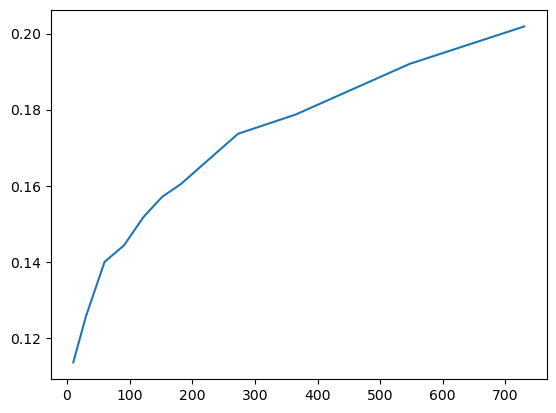

In [ ]:
plt.plot(dfATM.days[0:11],dfATM.impl_volatility[0:11])

In [ ]:
pivot_dfATM = dfATM.pivot(index='date',
                      columns = ['days','cp_flag'],
                      values = 'impl_volatility'
                      )
# Flatten columns
pivot_dfATM.columns = [f"{cp}_{day}" for day, cp in pivot_dfATM.columns]

In [ ]:
pivot_dfATM.loc[:,'C_10']
pivot_dfATM.index

Index(['2013-01-02', '2013-01-03', '2013-01-04', '2013-01-07', '2013-01-08',
       '2013-01-09', '2013-01-10', '2013-01-11', '2013-01-14', '2013-01-15',
       ...
       '2023-08-18', '2023-08-21', '2023-08-22', '2023-08-23', '2023-08-24',
       '2023-08-25', '2023-08-28', '2023-08-29', '2023-08-30', '2023-08-31'],
      dtype='object', name='date', length=2685)

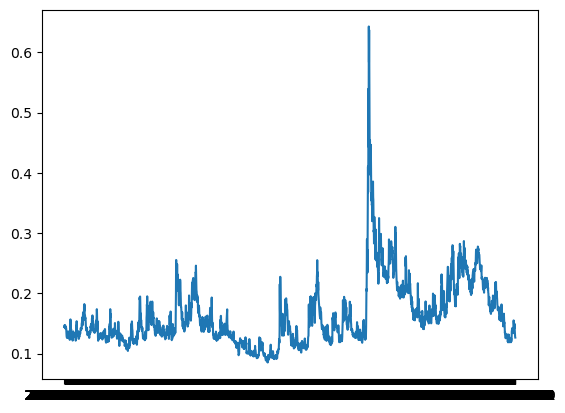

In [ ]:
plt.plot(pivot_dfATM.index,pivot_dfATM.loc[:,'C_91'])

# Big File with all moneyness and underlying assets (individual stocks incl. AAPL)

## Number of observation per companies

In [ ]:
#around 2-3 min to load
secidList = pd.read_csv('OldAppleOptionData/optionsAll_All2013_2023.csv', usecols=['secid'])

In [ ]:
uniqueSecid=secidList.value_counts()
uniqueSecid.index=uniqueSecid.index.get_level_values('secid')
uniqueSecid = uniqueSecid.to_frame(name='count')

In [ ]:
keyList = pd.read_csv('OldAppleOptionData/secidKey.csv')

In [ ]:
result = uniqueSecid.merge(keyList, left_index=True, right_on='secid', how='left')
result = result.set_index('secid')
obsPerComp=result[['count', 'TICKER', 'COMNAM']]

## Extracting data for a specific underlying asset

In [ ]:
# aroud 5 min to load
keyList = pd.read_csv('OldAppleOptionData/secidKey.csv')

## extracting secid for Apple Options
secid = keyList['secid'][keyList['TICKER']=='AAPL'].item()

file_path = 'OldAppleOptionData/optionsAll_All2013_2023.csv'

## Prepare an empty list to store matching rows
matching_rows = []

## Read in chunks
chunksize = 100_000  # adjust based on your memory
for chunk in pd.read_csv(file_path, chunksize=chunksize):
    filtered = chunk[chunk['secid'] == secid]
    if not filtered.empty:
        matching_rows.append(filtered)

## Concatenate all matching rows
result_df = pd.concat(matching_rows, ignore_index=True)
result_df

In [ ]:
result_df.to_csv("/Users/macbook/Documents/O_Research/data/OldAppleOptionData/optionsAll_AAPL.csv")

### Look at 1 day volatility surface

In [ ]:
result_df = pd.read_csv("/Users/macbook/Documents/O_Research/data/OldAppleOptionData/optionsAll_AAPL.csv")
result_df

,Unnamed: 0,secid,date,exdate,cp_flag,strike_price,volume,open_interest,impl_volatility,opprc,moneyness,tte,close,spread,mod_open_interest,noi
0,0,101594,2013-01-02,2013-01-11,C,495000,11,81,0.369411,54.200,0.901590,9,549.03,1.00,89.0,89.0
1,1,101594,2013-01-02,2013-01-11,C,500000,751,950,0.359700,49.325,0.910697,9,549.03,0.65,526.0,526.0
2,2,101594,2013-01-02,2013-01-11,C,505000,94,248,0.362135,44.625,0.919804,9,549.03,0.95,244.0,244.0
3,3,101594,2013-01-02,2013-01-11,C,510000,185,751,0.353525,39.925,0.928911,9,549.03,0.85,629.0,629.0
4,4,101594,2013-01-02,2013-01-11,C,515000,148,700,0.338276,35.225,0.938018,9,549.03,0.45,658.0,658.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3206418,3206418,101594,2023-08-31,2025-12-19,P,225000,0,769,0.237182,41.825,1.197637,841,187.87,2.95,NaN,NaN
3206419,3206419,101594,2023-08-31,2025-12-19,P,230000,0,157,0.238090,45.700,1.224251,841,187.87,2.30,NaN,NaN
3206420,3206420,101594,2023-08-31,2025-12-19,P,235000,0,10,0.228530,49.000,1.250865,841,187.87,2.80,NaN,NaN
3206421,3206421,101594,2023-08-31,2025-12-19,P,240000,0,4,0.227702,53.200,1.277479,841,187.87,2.80,NaN,NaN


In [ ]:
rowToSel = result_df['date']=='2020-01-16'
rowId = rowToSel.index[rowToSel == True]
data1date = result_df.iloc[rowId,:]

#reduce surface area
data1date = data1date[data1date['cp_flag']=='C']
data1date = data1date[data1date['tte']<200]

# Extract X (moneyness), Y (tte), Z (implied volatility)
x = data1date['moneyness']
y = data1date['tte']
z = data1date['impl_volatility']

# Same interpolation
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((x, y), z, (xi, yi), method='linear')

# Plotly surface
fig = go.Figure(data=[go.Surface(z=zi, x=xi, y=yi, colorscale='Viridis')])
fig.update_layout(
    title='Implied Volatility Surface',
    scene=dict(
        xaxis_title='Moneyness',
        yaxis_title='Time to Expiration (TTE)',
        zaxis_title='Implied Volatility'
    )
)
fig.show()

### Look at average volatility surface

In [ ]:
roundedDf = result_df
roundedDf['moneyness'] = result_df['moneyness'].round(4)

#reduce surface area
roundedDf = roundedDf[roundedDf['cp_flag']=='P']
roundedDf = roundedDf[roundedDf['tte']<200]

# take average implVolatility
averageImpl=(roundedDf.groupby(['tte','moneyness'])['impl_volatility'].mean().reset_index())

# Extract X (moneyness), Y (tte), Z (implied volatility)
x = averageImpl['moneyness']
y = averageImpl['tte']
z = averageImpl['impl_volatility']

# Same interpolation
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((x, y), z, (xi, yi), method='linear')

# Plotly surface
fig = go.Figure(data=[go.Surface(z=zi, x=xi, y=yi, colorscale='Viridis')])
fig.update_layout(
    title='Implied Volatility Surface',
    scene=dict(
        xaxis_title='Moneyness',
        yaxis_title='Time to Expiration (TTE)',
        zaxis_title='Implied Volatility'
    )
)
fig.show()

## Normalize data and save data

In [ ]:
cleanIVS = result_df[result_df['cp_flag']=='C']
cleanIVS = cleanIVS[['date','moneyness', 'tte', 'impl_volatility']].copy()
cleanIVS.to_csv("/Users/macbook/Documents/O_Research/data/OldAppleOptionData/optionsIVS_AAPL.csv", index=False)

998


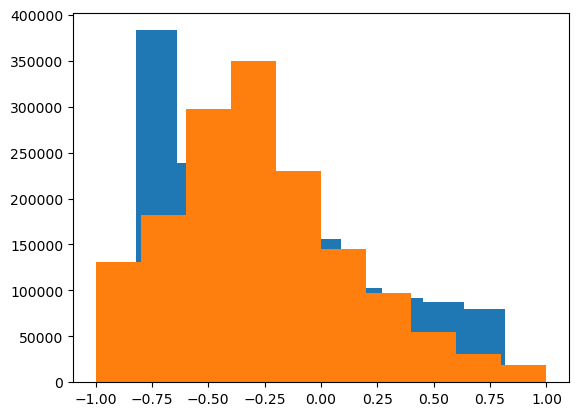

In [ ]:
#Normalize axis
normalizedIVS = pd.read_csv("/Users/macbook/Documents/O_Research/data/OldAppleOptionData/optionsIVS_AAPL.csv")

#moneyness normalization 
maxMoneyness = 2   #those above 2 are too sparse an are problematic when projecting on basis fn
minMoneyness = .5  #those under .5 are too sparse an are problematic when projecting on basis fn
normalizedIVS = normalizedIVS[normalizedIVS['moneyness']<maxMoneyness]
normalizedIVS = normalizedIVS[normalizedIVS['moneyness']>minMoneyness]
normalizedIVS['moneynessNorm'] = 2*((normalizedIVS['moneyness']-minMoneyness)/(maxMoneyness-minMoneyness))-1

#tte normalization
print(normalizedIVS['tte'].max()) #lets use 1000 days is max maturity
maxTimeToExpiry = 1000
normalizedIVS['tteNorm'] = 2*((normalizedIVS['tte']/maxTimeToExpiry)**(1/2))-1 #use square root to avoid clustering in small values (maybe consider **(1/3), more uniformly distributed but no value close to -1)

#check histogram
plt.hist(normalizedIVS['tteNorm'])
plt.hist(normalizedIVS['moneynessNorm'])

#add Id for distinct dates
normalizedIVS = normalizedIVS.rename(columns={'Unnamed: 0':'dateID'})
uniqueDate = normalizedIVS['date'].unique()
for i in range(uniqueDate.__len__()):
    rowToSel = normalizedIVS['date']==uniqueDate[i]
    rowId = rowToSel.index[rowToSel == True]
    normalizedIVS.loc[rowId, 'dateID']= np.repeat(i, rowToSel.sum())
    
    
normalizedIVS.to_csv("/Users/macbook/Documents/O_Research/data/OldAppleOptionData/optionsIVS_AAPL_normalized.csv", index=False)

### Put data in a format that FuNVol can work with

In [ ]:
AAPL = pd.read_csv("/Users/macbook/Documents/O_Research/data/OldAppleOptionData/optionsAll_AAPL.csv")
AAPL = AAPL[AAPL['cp_flag']=='C']
AAPL = AAPL[['date', 'close','moneyness', 'tte', 'impl_volatility']].copy()

In [ ]:
#match col name with FuNVol function
AAPL = AAPL.rename(columns={'date':'dates', 'close':'prices', 'impl_volatility':'IV','tte':'tau'})

#remove extreme moneyness which are sparse and not good for basis projections
maxMoneyness = 2   #those above 2 are too sparse an are problematic when projecting on basis fn
minMoneyness = .5  #those under .5 are too sparse an are problematic when projecting on basis fn
AAPL = AAPL[AAPL['moneyness']<maxMoneyness]
AAPL = AAPL[AAPL['moneyness']>minMoneyness]

AAPL

,dates,prices,moneyness,tau,IV
0,2013-01-02,549.03,0.901590,9,0.369411
1,2013-01-02,549.03,0.910697,9,0.359700
2,2013-01-02,549.03,0.919804,9,0.362135
3,2013-01-02,549.03,0.928911,9,0.353525
4,2013-01-02,549.03,0.938018,9,0.338276
...,...,...,...,...,...
3205883,2023-08-31,187.87,1.437164,841,0.230904
3205884,2023-08-31,187.87,1.490392,841,0.229115
3205885,2023-08-31,187.87,1.543621,841,0.227446
3205886,2023-08-31,187.87,1.596849,841,0.225945


In [ ]:
#save it as a .pkl python object
with open("/Users/macbook/Documents/O_Research/data/OldAppleOptionData/AAPL.pkl", "wb") as f:
    pickle.dump(AAPL, f)

## Clean Data AAPL with Deltas

In [ ]:
deltaData = pd.read_csv("/Users/macbook/Documents/O_Research/data/OldAppleOptionData/optionsIVS_AAPL_Delta.csv")
priceData = pd.read_csv("/Users/macbook/Documents/O_Research/data/OldAppleOptionData/optionsAll_AAPL.csv", usecols= ['date', 'close'])
priceData.drop_duplicates(inplace=True, ignore_index=True)

# Map the 'date' in deltaData to the 'close' value in priceData
deltaData['prices'] = deltaData['date'].map(priceData.set_index('date')['close'])

#only keep date for which we also have stock price information
deltaDataPrices = deltaData[~deltaData['prices'].isna()]
deltaDataPrices = deltaDataPrices[['date', 'prices','days', 'delta', 'impl_volatility', 'impl_strike', 'impl_premium']].copy()
deltaDataPrices.to_csv("/Users/macbook/Documents/O_Research/data/OldAppleOptionData/optionsIVS_AAPL_DeltaAndPrices.csv", index=False)


# SPX Data Wrangling

## Clean SPX data

In [ ]:
rawOptionsData = pd.read_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_optionsIVS.csv")
rawDividendsData = pd.read_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_dividendsYield.csv")
rawPriceData = pd.read_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_prices.csv")
rawYieldData = pd.read_csv("/Users/macbook/Documents/O_Research/data/SPX_data/ZeroCouponBond_Yields.csv")

/var/folders/92/k401vmms1193d1k1k1w1lss80000gn/T/ipykernel_12956/3178309862.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  rawOptionsData = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_optionsIVS.csv")


In [3]:
#remove misspecified data
optionData = rawOptionsData[['date', 'exdate', 'am_settlement', 'cp_flag', 'strike_price', 'best_bid', 'best_offer', 'impl_volatility', 'open_interest', 'volume']]
optionData = optionData[~optionData['impl_volatility'].isna()]
optionData['strike_price'] = optionData['strike_price']/1000

In [4]:
#compute time to expiry
optionData['date'] = pd.to_datetime(optionData['date'])
optionData['exdate'] = pd.to_datetime(optionData['exdate'])
## The column am_settlement is 1 if option epiry at market open, meaning that it is not traded the day of expiry, 
## while it is 0 if it epiry at close, meaning that we don't lose any day of trading. Hence why we substract am_settlement
optionData['tte'] = (optionData['exdate']-optionData['date']).dt.days- optionData['am_settlement']
#compute mid price
optionData['midPrices'] = np.average(optionData[['best_bid','best_offer']], axis=1)

In [5]:
#add price data to df
rawPriceData['date'] = pd.to_datetime(rawPriceData['date'])
optionData['assetPrices'] = optionData['date'].map(rawPriceData.set_index('date')['close'])

In [9]:
#add dividend data to df, the anualized dividend rate are the one used for the respective option expiry
rawDividendsData = rawDividendsData.rename(columns={'expiration':'exdate', 'rate':'dividendRate'})
rawDividendsData['date'] = pd.to_datetime(rawDividendsData['date'])
rawDividendsData['exdate'] = pd.to_datetime(rawDividendsData['exdate'])
optionData = optionData.merge(rawDividendsData[['date','exdate','dividendRate']], on=['date', 'exdate'], how = 'left')
optionData['dividendRate'] = optionData['dividendRate']/100

##some of the dividend rate are missing when 'tte' is one or two
print("tte when dividend yield are missing: ",optionData[optionData['dividendRate'].isna()]['tte'].unique())

##since for every case where the dividend yield is given for a tte <= 2 it is 0.0, we set all those missing dividend rate value as 0
optionData.loc[optionData['dividendRate'].isna(),'dividendRate'] = 0

tte when dividend yield are missing:  [1 2]


In [10]:
# Add interpolated risk-free rate used in Black-Schole

rawYieldData = rawYieldData.rename(columns={'rate':'rfRate'})
rawYieldData['date'] = pd.to_datetime(rawYieldData['date'])
## Ensure the yield data is sorted by date and days
rawYieldData = rawYieldData.sort_values(by=['date', 'days'])

## Initialize the new column with missing values
optionData['rfRate'] = pd.NA

missingRateDate = []
for current_date, option_group in optionData.groupby('date'):
    # Get the yield curve for this specific date
    yield_curve = rawYieldData[rawYieldData['date'] == current_date]
    
    # If there is no yield data for this date, skip it
    if yield_curve.empty:
        missingRateDate.append(current_date)
        continue
    
    x_days = yield_curve['days'].values
    y_rates = yield_curve['rfRate'].values
    
    # Create the interpolator
    # bounds_error=False: prevents errors when 'tte' falls outside the min/max 'days'
    # fill_value=(y_rates[0], y_rates[-1]): handles the flat extrapolation using the closest boundaries
    interpolator = interp1d(
        x_days, 
        y_rates, 
        kind='linear', 
        bounds_error=False, 
        fill_value=(y_rates[0], y_rates[-1])
    )
    
    # Calculate the rates for the 'tte' values in the current group
    interpolated_rates = interpolator(option_group['tte'].values)
    
    # Assign the calculated rates back to the original optionData dataframe
    optionData.loc[option_group.index, 'rfRate'] = interpolated_rates/100

In [11]:
# Average out yield curve of the day before and after for the missing dates
for date in missingRateDate:
    option_group = optionData[optionData['date']==date]
    
    prevDate = optionData['date'][optionData['date'] < date].max()
    nextDate = optionData['date'][optionData['date'] > date].min()
    
    # Get the yield curve for this specific date
    prev_yield_curve = rawYieldData[rawYieldData['date'] == prevDate]
    next_yield_curve = rawYieldData[rawYieldData['date'] == nextDate]
    
    prev_x_days = prev_yield_curve['days'].values
    prev_y_rates = prev_yield_curve['rfRate'].values
    
    next_x_days = next_yield_curve['days'].values
    next_y_rates = next_yield_curve['rfRate'].values
    
    # Create the interpolator
    # bounds_error=False: prevents errors when 'tte' falls outside the min/max 'days'
    # fill_value=(y_rates[0], y_rates[-1]): handles the flat extrapolation using the closest boundaries
    prev_interpolator = interp1d(
        prev_x_days, 
        prev_y_rates, 
        kind='linear', 
        bounds_error=False, 
        fill_value=(prev_y_rates[0], prev_y_rates[-1])
    )
    
    next_interpolator = interp1d(
        next_x_days, 
        next_y_rates, 
        kind='linear', 
        bounds_error=False, 
        fill_value=(next_y_rates[0], next_y_rates[-1])
    )
    
    # Calculate the rates for the 'tte' values in the current group
    prev_interpolated_rates = prev_interpolator(option_group['tte'].values)
    next_interpolated_rates = next_interpolator(option_group['tte'].values)
    
    # Assign the calculated rates back to the original optionData dataframe
    optionData.loc[option_group.index, 'rfRate'] = np.mean([prev_interpolated_rates,next_interpolated_rates])/100

In [12]:
optionData['rfRate'] = optionData['rfRate'].astype('float64')

In [13]:
# Assuming 'tte' is in days. If it is already in years, remove the " / 365.0"
tau = optionData['tte'] / 365 

# Calculate the present value of the asset (discounted by the dividend yield)
pv_asset = optionData['assetPrices'] * np.exp(-(optionData['dividendRate'] * tau))

# Calculate the present value of the strike price (discounted by the risk-free rate)
pv_strike = optionData['strike_price'] * np.exp(-(optionData['rfRate'] * tau))

# Compute the theoretical lower arbitrage bounds for calls and puts
call_lower_bound = np.maximum(0, pv_asset - pv_strike)
put_lower_bound = np.maximum(0, pv_strike - pv_asset)

# Create boolean masks to find options that respect the minimum price limits
is_valid_call = (optionData['cp_flag'] == 'C') & (optionData['midPrices'] >= call_lower_bound)
is_valid_put = (optionData['cp_flag'] == 'P') & (optionData['midPrices'] >= put_lower_bound)

# Apply the filter: Keep rows that are EITHER valid calls OR valid puts
arbitrage_free_optionData = optionData[is_valid_call | is_valid_put].copy()

In [14]:
print("there was",optionData.__len__() - arbitrage_free_optionData.__len__(),"observations with arbitrage")

there was 45568 observations with arbitrage


In [15]:
# 1. Count how many options exist for each combination (A count of 2 means both a Call and Put exist)
counts = arbitrage_free_optionData.groupby(['date', 'exdate', 'am_settlement', 'strike_price'])['cp_flag'].transform('count')

# 2. Define the Out-Of-The-Money (OTM) conditions
# A Call is OTM if the Strike Price is greater than the Asset Price
is_otm_call = (arbitrage_free_optionData['cp_flag'] == 'C') & (arbitrage_free_optionData['strike_price'] > arbitrage_free_optionData['assetPrices'])

# A Put is OTM if the Strike Price is less than or equal to the Asset Price 
# (Using <= handles the exact At-The-Money edge case so you don't drop both)
is_otm_put = (arbitrage_free_optionData['cp_flag'] == 'P') & (arbitrage_free_optionData['strike_price'] <= arbitrage_free_optionData['assetPrices'])

# 3. Create a filter mask: 
# Keep the row if it's the ONLY option available for that strike (count == 1) OR if it is the OTM option
keep_mask = (counts == 1) | is_otm_call | is_otm_put

# 4. Apply the mask to filter the DataFrame
filtered_optionData = arbitrage_free_optionData[keep_mask].copy()


In [16]:
print("there was",arbitrage_free_optionData.__len__() - filtered_optionData.__len__(),"duplicate put-call options with no arbitrage")

there was 17441679 duplicate put-call options with no arbitrage


In [17]:
# Save Data
filtered_optionData.to_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_allData.csv", index=False)

## Liquidity test

In [211]:
optionDataNotCleaned = pd.read_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_allData.csv")
print(optionDataNotCleaned.__len__())
#pre scale data
optionDataNotCleaned['tte_year'] = (optionDataNotCleaned['tte'])/365

21115112


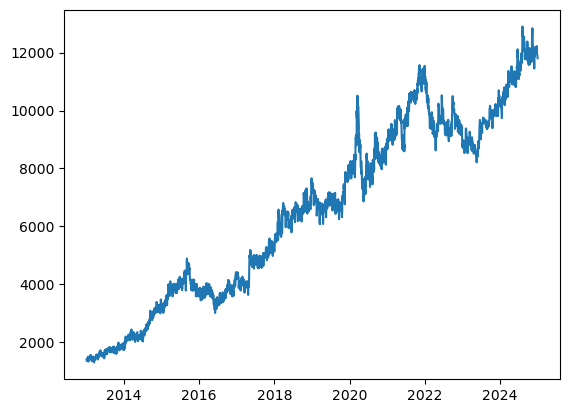

In [212]:
# check nb of observation per day ~1min
optionDataNotCleaned['date'] = pd.to_datetime(optionDataNotCleaned['date'])
nbObsPerDay = optionDataNotCleaned['date'].value_counts().sort_index()

nbTest = nbObsPerDay[nbObsPerDay.index >= '2013-01-01']
_ = plt.plot(nbTest)

In [15]:
#get more measurments
optionDataNotCleaned['impl_volatility_timeScaled'] = optionDataNotCleaned['impl_volatility']*np.sqrt(optionDataNotCleaned['tte_year'])
optionDataNotCleaned['forward'] = optionDataNotCleaned['assetPrices']*np.exp((optionDataNotCleaned['rfRate']-optionDataNotCleaned['dividendRate'])*(optionDataNotCleaned['tte_year']))
optionDataNotCleaned['discountFactors'] = np.exp((optionDataNotCleaned['rfRate'])*(-optionDataNotCleaned['tte_year']))

optionDataNotCleaned['logForwardMoneynessTimeScaled'] = (1/np.sqrt(optionDataNotCleaned['tte_year']))*np.log(optionDataNotCleaned['strike_price']/optionDataNotCleaned['forward'])
optionDataNotCleaned['logForwardMoneyness'] = np.log(optionDataNotCleaned['strike_price']/optionDataNotCleaned['forward'])
optionDataNotCleaned['ForwardMoneyness'] = (optionDataNotCleaned['strike_price']/optionDataNotCleaned['forward'])

optionDataNotCleaned['logMoneynessTimeScaled'] = (1/np.sqrt(optionDataNotCleaned['tte_year']))*np.log(optionDataNotCleaned['strike_price']/optionDataNotCleaned['assetPrices'])
optionDataNotCleaned['logMoneyness'] = np.log(optionDataNotCleaned['strike_price']/optionDataNotCleaned['assetPrices'])
optionDataNotCleaned['Moneyness'] = (optionDataNotCleaned['strike_price']/optionDataNotCleaned['assetPrices'])



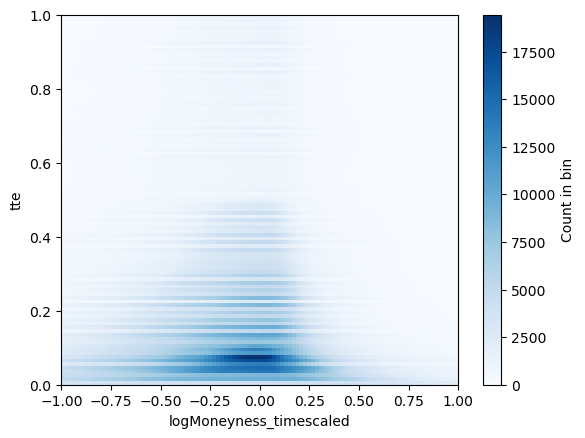

In [48]:
# Sample data
x = optionDataNotCleaned['logMoneynessTimeScaled']
y = optionDataNotCleaned['tte']/365

# Create the heatmap
plt.hist2d(x, y, bins=100, cmap='Blues', range=[[-1, 1], [0, 1]])
plt.colorbar(label='Count in bin')

plt.xlabel('logMoneyness_timescaled')
plt.ylabel('tte')
plt.show()

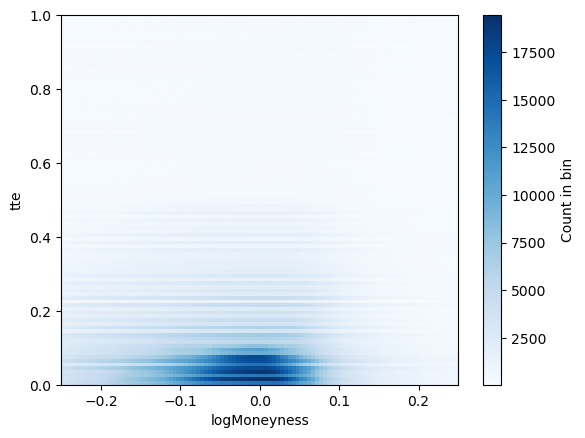

In [49]:
# Sample data
x = optionDataNotCleaned['logMoneyness']
y = optionDataNotCleaned['tte']/365

# Create the heatmap
plt.hist2d(x, y, bins=100, cmap='Blues', range=[[-.25, .25], [0, 1]])
plt.colorbar(label='Count in bin')

plt.xlabel('logMoneyness')
plt.ylabel('tte')
plt.show()

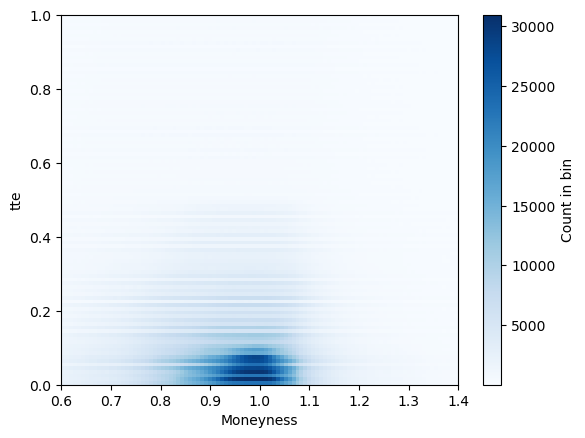

In [50]:
# Sample data
x = optionDataNotCleaned['Moneyness']
y = optionDataNotCleaned['tte']/365

# Create the heatmap
plt.hist2d(x, y, bins=100, cmap='Blues', range=[[.6, 1.4], [0, 1]])
plt.colorbar(label='Count in bin')

plt.xlabel('Moneyness')
plt.ylabel('tte')
plt.show()

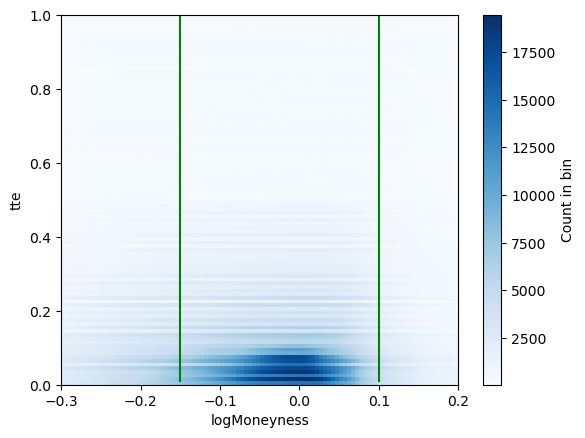

In [17]:
maxLogMoney = .1
minLogMoney = -.15

# Sample data
x = optionDataNotCleaned['logMoneyness']
y = optionDataNotCleaned['tte']/365

# Create the heatmap
plt.hist2d(x, y, bins=100, cmap='Blues', range=[[minLogMoney*2, maxLogMoney*2], [0, 1]])
plt.colorbar(label='Count in bin')

# plt.plot((maxLogMoney*np.sqrt(np.linspace(0.01,1,365))),np.linspace(0.01,1,365), c = 'g')
# plt.plot((minLogMoney*np.sqrt(np.linspace(0.01,1,365))),np.linspace(0.01,1,365), c = 'g')

plt.plot(np.repeat(maxLogMoney,365),np.linspace(0.01,1,365), c = 'g')
plt.plot(np.repeat(minLogMoney,365),np.linspace(0.01,1,365), c = 'g')

plt.xlabel('logMoneyness')
plt.ylabel('tte')
plt.show()

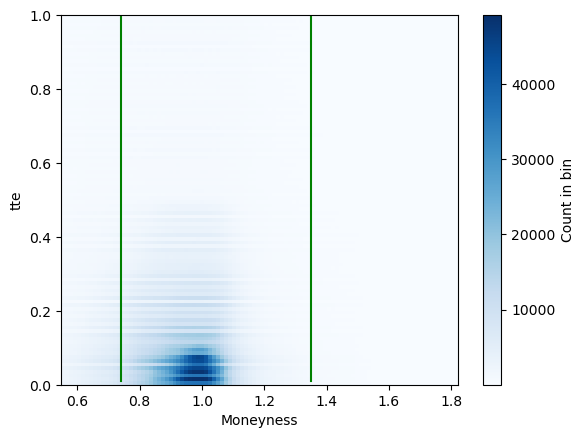

In [67]:
# Sample data
x = optionDataNotCleaned['Moneyness']
y = optionDataNotCleaned['tte']/365

# Create the heatmap
plt.hist2d(x, y, bins=100, cmap='Blues', range=[[np.exp(minLogMoney*2), np.exp(maxLogMoney*2)], [0, 1]])
plt.colorbar(label='Count in bin')

# plt.plot((maxLogMoney*np.sqrt(np.linspace(0.01,1,365))),np.linspace(0.01,1,365), c = 'g')
# plt.plot((minLogMoney*np.sqrt(np.linspace(0.01,1,365))),np.linspace(0.01,1,365), c = 'g')

plt.plot(np.repeat(np.exp(maxLogMoney),365),np.linspace(0.01,1,365), c = 'g')
plt.plot(np.repeat(np.exp(minLogMoney),365),np.linspace(0.01,1,365), c = 'g')

plt.xlabel('Moneyness')
plt.ylabel('tte')
plt.show()

In [42]:
#Could go up to 370 tte to increase obs at the edge to help with B-splines
optionDataLiquid = optionDataNotCleaned[(optionDataNotCleaned['logMoneyness']<=maxLogMoney)&(optionDataNotCleaned['logMoneyness']>=minLogMoney)&(optionDataNotCleaned['tte']<=365)]

In [72]:
optionDataLiquid['logMoneyness'].describe()

count    1.080369e+07
mean    -2.488719e-02
std      6.512093e-02
min     -1.499998e-01
25%     -7.686542e-02
50%     -2.244403e-02
75%      2.693914e-02
max      9.999882e-02
Name: logMoneyness, dtype: float64

In [76]:
optionDataLiquid.to_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_allData_liquid.csv", index=False)

## Verifying IVS calculation in SPX data

In [78]:
optionDataLiquid = pd.read_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_allData_liquid.csv")

In [79]:
optionData = optionDataLiquid.copy()

#create empty vector of IV and price based on their IV
implVolVec = []
implMidPrice = []

#compute all IVs
for index, row in optionData[['strike_price','impl_volatility_timeScaled','tte_year','midPrices', 'forward','discountFactors', 'cp_flag']].iterrows():
    print(index) if index%1000000 == 0 else ""
    strike, implVol, tau, callMidPrice, forward, discountFactor, cp_flag = row
    callOrPut = ql.Option.Call if cp_flag == 'C' else ql.Option.Put
    implMidPrice.append(ql.blackFormula(callOrPut,strike,forward,implVol, discountFactor))
    try:
        ivsTemp = ql.blackFormulaImpliedStdDev(callOrPut, strike, forward, callMidPrice, discountFactor, 0.0, implVol)
    except RuntimeError:
        ivsTemp = 0
    implVolVec.append(ivsTemp)
   
implVolVec = implVolVec/np.sqrt(optionData['tte_year'])

0
1000000
2000000
3000000
4000000
5000000
6000000
7000000
8000000
9000000
10000000


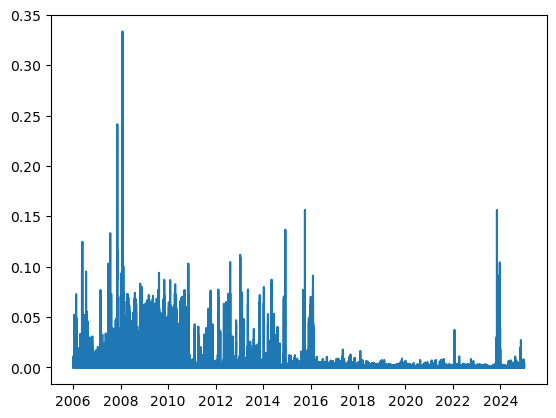

In [80]:
percentErrorPrice = np.abs(implMidPrice - optionData['midPrices'])/optionData['midPrices']
percentErrorVol = np.abs(implVolVec - optionData['impl_volatility'])/optionData['impl_volatility']
optionData['date'] = pd.to_datetime(optionData['date'])
_=plt.plot(optionData['date'],percentErrorVol)
#plt.plot(optionData['tte'].iloc[minEvalIndex:(minEvalIndex+maxEvalIndex)]/36500)
#plt.plot(optionData['date'].iloc[minEvalIndex:(minEvalIndex+maxEvalIndex)].diff().dt.days/200)
#plt.plot(optionData['date'].iloc[minEvalIndex:(minEvalIndex+maxEvalIndex)].dt.month.diff()*1)

In [81]:
optionData['errorPrice'] = np.nan
optionData['errorPrice'] = np.round(percentErrorPrice,4)
print("percent of options with >= .01 error in mid-price computed from given IV:", np.sum(optionData['errorPrice']>=0.01)/optionData.__len__())

percent of options with >= .01 error in mid-price computed from given IV: 0.009315705160393794


In [82]:
optionData['impl_volatility_computed'] = implVolVec
optionData['errorVol'] = np.nan
optionData['errorVol'] = np.round(percentErrorVol,4)
print("percent of options with >= .01 error in computed IV:", np.sum(optionData['errorVol']>=0.01)/optionData.__len__())
optionData[optionData['errorVol']>=0.01]

percent of options with >= .01 error in computed IV: 0.003415221705248697


,date,exdate,am_settlement,cp_flag,strike_price,best_bid,best_offer,impl_volatility,open_interest,volume,...,discountFactors,logForwardMoneynessTimeScaled,logMoneyness,Moneyness,logForwardMoneyness,ForwardMoneyness,logMoneynessTimeScaled,errorPrice,impl_volatility_computed,errorVol
96,2006-01-03,2006-01-21,1,C,1270.0,9.7,11.3,0.089610,22125,2864,...,0.997952,-0.004372,0.000945,1.000946,-0.000944,0.999057,0.004380,0.0102,0.090595,0.0110
1526,2006-01-17,2006-02-18,1,C,1300.0,9.4,10.0,0.099893,25489,5698,...,0.996158,0.033162,0.013218,1.013305,0.009664,1.009711,0.045355,0.0148,0.100902,0.0101
1559,2006-01-17,2006-02-18,1,C,1285.0,16.7,17.9,0.106222,1276,4464,...,0.996158,-0.006661,0.001612,1.001613,-0.001941,0.998061,0.005532,0.0117,0.107581,0.0128
1560,2006-01-17,2006-02-18,1,C,1290.0,14.0,15.2,0.104736,9287,1444,...,0.996158,0.006665,0.005496,1.005511,0.001942,1.001944,0.018858,0.0125,0.105965,0.0117
1561,2006-01-17,2006-02-18,1,C,1295.0,11.5,12.7,0.102885,1243,99,...,0.996158,0.019939,0.009364,1.009408,0.005811,1.005828,0.032132,0.0135,0.103999,0.0108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10555990,2024-11-11,2024-12-20,1,P,5980.0,75.0,75.7,0.124431,2854,9,...,0.995028,-0.025202,-0.003564,0.996442,-0.008132,0.991901,-0.011045,0.0265,0.127080,0.0213
10555991,2024-11-11,2024-12-20,1,P,5985.0,76.8,77.4,0.123856,1411,17,...,0.995028,-0.022612,-0.002728,0.997276,-0.007296,0.992731,-0.008455,0.0264,0.126547,0.0217
10555992,2024-11-11,2024-12-20,1,P,5990.0,78.6,79.2,0.123296,3506,11,...,0.995028,-0.020024,-0.001893,0.998109,-0.006461,0.993560,-0.005867,0.0263,0.126026,0.0221
10555993,2024-11-11,2024-12-20,1,P,5995.0,80.4,81.1,0.122751,2879,29,...,0.995028,-0.017438,-0.001059,0.998942,-0.005627,0.994389,-0.003281,0.0262,0.125524,0.0226


In [83]:
optionDataReviewed = optionData[~(optionData['errorVol']>=0.01)]

In [84]:
optionDataReviewedClean = optionDataReviewed[['date', 'tte', 'strike_price', 'assetPrices', 'impl_volatility_computed', 'midPrices', 'rfRate', 'dividendRate', 'cp_flag']]
optionDataReviewedClean.to_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_allData_cleaned_liquid.csv", index=False)

In [86]:
##Optional Remove options with 0 open interest or 0 volume
optionDataReviewedTraded = optionDataReviewed[~(optionDataReviewed['open_interest']<=0)]
optionDataReviewedTraded = optionDataReviewedTraded[~(optionDataReviewedTraded['volume']<=0)]
optionDataReviewedTraded = optionDataReviewedTraded[['date', 'tte', 'strike_price', 'assetPrices', 'impl_volatility_computed', 'midPrices', 'rfRate', 'dividendRate', 'cp_flag']]
optionDataReviewedTraded.to_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_allData_cleaned_liquid_traded.csv", index=False)

## Format Data as a list

A panda list where each component in the list is the data for a given day

In [221]:
# can take quite some time (~40 min)

optionData = pd.read_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_allData_cleaned_liquid.csv")

uniqueDates = optionData['date'].unique()    

S = []
rfRate = []
dividendRate=[]
tau = []
moneyness = []
iv = []
    
for date in uniqueDates:
    singleDayData = optionData[optionData['date'] == date]
    S.append(singleDayData['assetPrices'].unique()[0])
    rfRate.append(singleDayData['rfRate'])
    dividendRate.append(singleDayData['dividendRate'])
    tau.append(singleDayData['tte']/365)
    moneyness.append(singleDayData['strike_price']/singleDayData['assetPrices'])
    iv.append(singleDayData['impl_volatility_computed'])

with open("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_lists.pkl", "wb") as f:
    pickle.dump(uniqueDates, f)
    pickle.dump(tau, f)
    pickle.dump(moneyness, f)
    pickle.dump(iv, f)
    pickle.dump(S, f)
    pickle.dump(rfRate, f)
    pickle.dump(dividendRate, f)

In [3]:
optionData = pd.read_csv("/Users/macbook/Documents/O_Research/data/SPX_data/SPX_allData_cleaned_liquid.csv")


In [43]:
(optionData[optionData['tte']>=365]['date']).unique().__len__()/optionData['date'].unique().__len__()


0.028027609286760093

# Liquidity Check

In [11]:
rawOptionsData = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_optionsIVS.csv")

/var/folders/92/k401vmms1193d1k1k1w1lss80000gn/T/ipykernel_11089/2809484541.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  rawOptionsData = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_optionsIVS.csv")


In [12]:
#remove misspecified data
optionData = rawOptionsData[['date', 'exdate', 'am_settlement', 'cp_flag', 'strike_price', 'best_bid', 'best_offer', 'impl_volatility', 'open_interest', 'volume']]
optionData = optionData[~optionData['impl_volatility'].isna()]
optionData['strike_price'] = optionData['strike_price']/1000
#compute time to expiry
optionData['date'] = pd.to_datetime(optionData['date'])
optionData['exdate'] = pd.to_datetime(optionData['exdate'])
## The column am_settlement is 1 if option epiry at market open, meaning that it is not traded the day of expiry, 
## while it is 0 if it epiry at close, meaning that we don't lose any day of trading. Hence why we substract am_settlement
optionData['tte'] = (optionData['exdate']-optionData['date']).dt.days- optionData['am_settlement']
#compute mid price
optionData['midPrices'] = np.average(optionData[['best_bid','best_offer']], axis=1)

141


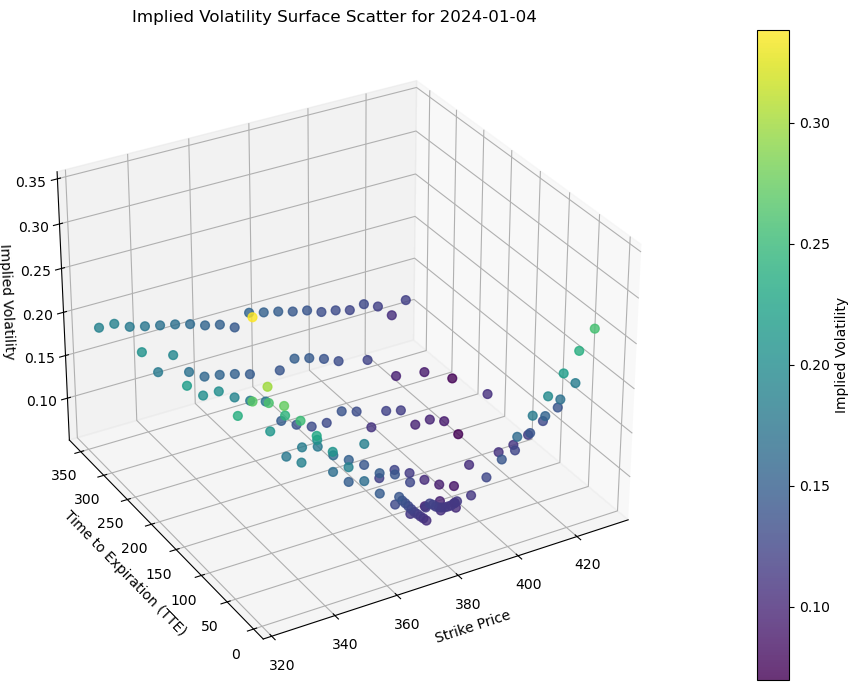

In [ ]:
# %matplotlib ipympl
# %matplotlib inline #it sets back the jupiter session to show static figure inline


# --- Configuration ---
# Replace this with the specific date you want to filter for
plotDate = "2024-01-04"

# Viewing angle parameters:
# elev = elevation angle in degrees (vertical rotation)
# azim = azimuthal angle in degrees (horizontal rotation)
view_elevation = 30
view_azimuth = 240

# --- Filter the Data ---
# Filtering the optionData DataFrame for the chosen date
df_filtered = optionData[optionData["date"] == plotDate]

print(df_filtered.__len__())

# --- Plotting ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Create the 3D scatter plot
# We map color (c) to implied volatility and use a colormap ('viridis') for better visuals
scatter = ax.scatter(
    df_filtered["strike_price"],
    df_filtered["tte"],
    df_filtered["impl_volatility"],
    c=df_filtered["impl_volatility"],
    cmap="viridis",
    s=40,  # Size of the points
    alpha=0.8,
)

# Set labels for the axes
ax.set_xlabel("Strike Price")
ax.set_ylabel("Time to Expiration (TTE)")
ax.set_zlabel("Implied Volatility")
ax.set_title(f"Implied Volatility Surface Scatter for {plotDate}")

# Add a color bar to map colors to exact volatility values
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Implied Volatility")

# --- Set the Viewing Angle ---
ax.view_init(elev=view_elevation, azim=view_azimuth)

# Display the plot
plt.tight_layout()
plt.show()


In [ ]:
# check nb of observation per day ~1min
optionData['date'] = pd.to_datetime(optionData['date'])
nbObsPerDay = optionData['date'].value_counts().sort_index()

In [15]:
%matplotlib inline

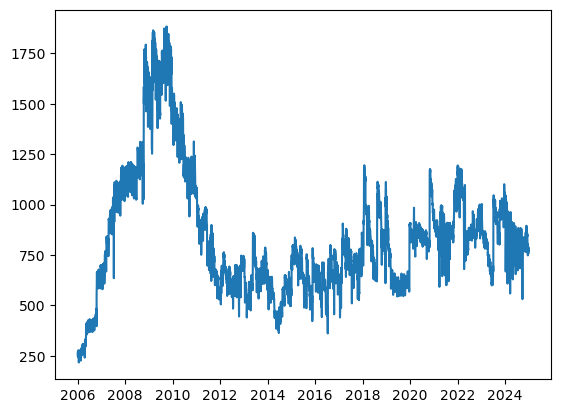

In [ ]:
_ = plt.plot(nbObsPerDay)

# DJX Data Wrangling

## Clean DJX data

In [173]:
rawOptionsData = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_optionsIVS.csv",low_memory=False)
rawDividendsData = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_dividendsYield.csv")
rawPriceData = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_prices.csv")
rawYieldData = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/ZeroCouponBond_Yields.csv")

In [174]:
#remove misspecified data
optionData = rawOptionsData[['date', 'exdate', 'am_settlement', 'cp_flag', 'strike_price', 'best_bid', 'best_offer', 'impl_volatility', 'open_interest', 'volume']]
optionData = optionData[~optionData['impl_volatility'].isna()]
optionData['strike_price'] = optionData['strike_price']/1000

In [175]:
#compute time to expiry
optionData['date'] = pd.to_datetime(optionData['date'])
optionData['exdate'] = pd.to_datetime(optionData['exdate'])
## check if its old settlement rule where expiry was on a saturday but trading ended on Friday AM - or practically on thursday at closing
optionData['is_saturday'] = (optionData['exdate'].dt.dayofweek == 5).astype(int)
## The column am_settlement is 1 if option epiry at market open, meaning that it is not traded the day of expiry, 
## while it is 0 if it epiry at close, meaning that we don't lose any day of trading. Hence why we substract am_settlement
optionData['tte'] = (optionData['exdate']-optionData['date']).dt.days - optionData['am_settlement'] - optionData['is_saturday']
#compute mid price
optionData['midPrices'] = np.average(optionData[['best_bid','best_offer']], axis=1)

In [176]:
#add price data to df
rawPriceData['date'] = pd.to_datetime(rawPriceData['date'])
optionData['assetPrices'] = optionData['date'].map(rawPriceData.set_index('date')['close'])

In [177]:
#add dividend data to df, the anualized dividend rate are the one used for the respective option expiry
rawDividendsData = rawDividendsData.rename(columns={'rate':'dividendRate'})
rawDividendsData['date'] = pd.to_datetime(rawDividendsData['date'])
optionData = optionData.merge(rawDividendsData[['date','dividendRate']], on=['date'], how = 'left')
optionData['dividendRate'] = optionData['dividendRate']/100

##some of the dividend rate are missing when 'tte' is one or two
print("tte when dividend yield are missing: ",optionData[optionData['dividendRate'].isna()]['tte'].unique())

##since for every case where the dividend yield is given for a tte <= 2 it is 0.0, we set all those missing dividend rate value as 0
optionData.loc[optionData['dividendRate'].isna(),'dividendRate'] = 0

tte when dividend yield are missing:  []


In [178]:
# Add interpolated risk-free rate used in Black-Schole

rawYieldData = rawYieldData.rename(columns={'rate':'rfRate'})
rawYieldData['date'] = pd.to_datetime(rawYieldData['date'])
## Ensure the yield data is sorted by date and days
rawYieldData = rawYieldData.sort_values(by=['date', 'days'])

## Initialize the new column with missing values
optionData['rfRate'] = pd.NA

missingRateDate = []
for current_date, option_group in optionData.groupby('date'):
    # Get the yield curve for this specific date
    yield_curve = rawYieldData[rawYieldData['date'] == current_date]
    
    # If there is no yield data for this date, skip it
    if yield_curve.empty:
        missingRateDate.append(current_date)
        continue
    
    x_days = yield_curve['days'].values
    y_rates = yield_curve['rfRate'].values
    
    # Create the interpolator
    # bounds_error=False: prevents errors when 'tte' falls outside the min/max 'days'
    # fill_value=(y_rates[0], y_rates[-1]): handles the flat extrapolation using the closest boundaries
    interpolator = interp1d(
        x_days, 
        y_rates, 
        kind='linear', 
        bounds_error=False, 
        fill_value=(y_rates[0], y_rates[-1])
    )
    
    # Calculate the rates for the 'tte' values in the current group
    interpolated_rates = interpolator(option_group['tte'].values)
    
    # Assign the calculated rates back to the original optionData dataframe
    optionData.loc[option_group.index, 'rfRate'] = interpolated_rates/100

In [179]:
# Average out yield curve of the day before and after for the missing dates
for date in missingRateDate:
    option_group = optionData[optionData['date']==date]
    
    prevDate = optionData['date'][optionData['date'] < date].max()
    nextDate = optionData['date'][optionData['date'] > date].min()
    
    # Get the yield curve for this specific date
    prev_yield_curve = rawYieldData[rawYieldData['date'] == prevDate]
    next_yield_curve = rawYieldData[rawYieldData['date'] == nextDate]
    
    prev_x_days = prev_yield_curve['days'].values
    prev_y_rates = prev_yield_curve['rfRate'].values
    
    next_x_days = next_yield_curve['days'].values
    next_y_rates = next_yield_curve['rfRate'].values
    
    # Create the interpolator
    # bounds_error=False: prevents errors when 'tte' falls outside the min/max 'days'
    # fill_value=(y_rates[0], y_rates[-1]): handles the flat extrapolation using the closest boundaries
    prev_interpolator = interp1d(
        prev_x_days, 
        prev_y_rates, 
        kind='linear', 
        bounds_error=False, 
        fill_value=(prev_y_rates[0], prev_y_rates[-1])
    )
    
    next_interpolator = interp1d(
        next_x_days, 
        next_y_rates, 
        kind='linear', 
        bounds_error=False, 
        fill_value=(next_y_rates[0], next_y_rates[-1])
    )
    
    # Calculate the rates for the 'tte' values in the current group
    prev_interpolated_rates = prev_interpolator(option_group['tte'].values)
    next_interpolated_rates = next_interpolator(option_group['tte'].values)
    
    # Assign the calculated rates back to the original optionData dataframe
    optionData.loc[option_group.index, 'rfRate'] = np.mean([prev_interpolated_rates,next_interpolated_rates])/100

In [180]:
optionData['rfRate'] = optionData['rfRate'].astype('float64')

In [181]:
# Assuming 'tte' is in days. If it is already in years, remove the " / 365.0"
tau = optionData['tte'] / 365 

# Calculate the present value of the asset (discounted by the dividend yield)
pv_asset = optionData['assetPrices'] * np.exp(-(optionData['dividendRate'] * tau))

# Calculate the present value of the strike price (discounted by the risk-free rate)
pv_strike = optionData['strike_price'] * np.exp(-(optionData['rfRate'] * tau))

# Compute the theoretical lower arbitrage bounds for calls and puts
call_lower_bound = np.maximum(0, pv_asset - pv_strike)
put_lower_bound = np.maximum(0, pv_strike - pv_asset)

# Create boolean masks to find options that respect the minimum price limits
is_valid_call = (optionData['cp_flag'] == 'C') & (optionData['midPrices'] >= call_lower_bound)
is_valid_put = (optionData['cp_flag'] == 'P') & (optionData['midPrices'] >= put_lower_bound)

# Apply the filter: Keep rows that are EITHER valid calls OR valid puts
arbitrage_free_optionData = optionData[is_valid_call | is_valid_put].copy()

In [182]:
print("there was",optionData.__len__() - arbitrage_free_optionData.__len__(),"observations with arbitrage")

there was 57 observations with arbitrage


In [183]:
# 1. Count how many options exist for each combination (A count of 2 means both a Call and Put exist)
counts = arbitrage_free_optionData.groupby(['date', 'exdate', 'am_settlement', 'strike_price'])['cp_flag'].transform('count')

# 2. Define the Out-Of-The-Money (OTM) conditions
# A Call is OTM if the Strike Price is greater than the Asset Price
is_otm_call = (arbitrage_free_optionData['cp_flag'] == 'C') & (arbitrage_free_optionData['strike_price'] > arbitrage_free_optionData['assetPrices'])

# A Put is OTM if the Strike Price is less than or equal to the Asset Price 
# (Using <= handles the exact At-The-Money edge case so you don't drop both)
is_otm_put = (arbitrage_free_optionData['cp_flag'] == 'P') & (arbitrage_free_optionData['strike_price'] <= arbitrage_free_optionData['assetPrices'])

# 3. Create a filter mask: 
# Keep the row if it's the ONLY option available for that strike (count == 1) OR if it is the OTM option
keep_mask = (counts == 1) | is_otm_call | is_otm_put

# 4. Apply the mask to filter the DataFrame
filtered_optionData = arbitrage_free_optionData[keep_mask].copy()


In [184]:
print("there was",arbitrage_free_optionData.__len__() - filtered_optionData.__len__(),"duplicate put-call options with no arbitrage")

there was 1823379 duplicate put-call options with no arbitrage


In [185]:
# Save Data
filtered_optionData.to_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_allData.csv", index=False)

## Liquidity test

In [186]:
optionDataNotCleaned = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_allData.csv")
print(optionDataNotCleaned.__len__())
#pre scale data
optionDataNotCleaned['tte_year'] = (optionDataNotCleaned['tte'])/365

2253894


In [187]:
# check nb of observation per day ~1min
optionDataNotCleaned['date'] = pd.to_datetime(optionDataNotCleaned['date'])
nbObsPerDay = optionDataNotCleaned['date'].value_counts().sort_index()

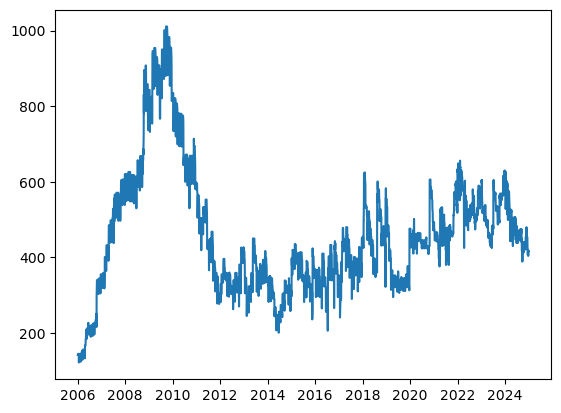

In [188]:
_ = plt.plot(nbObsPerDay)

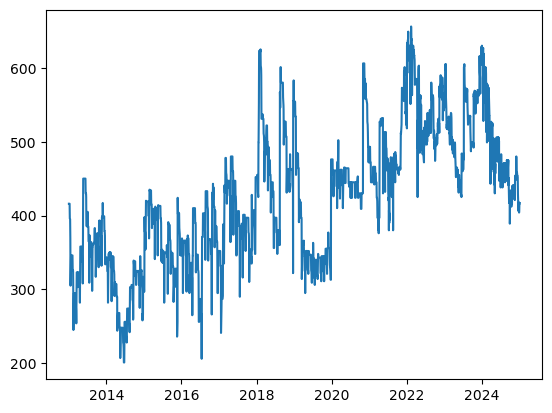

In [189]:
nbTest = nbObsPerDay[nbObsPerDay.index >= '2013-01-01']
_ = plt.plot(nbTest)

In [190]:
# only keep 12 years of data 2013-01-01 to 2024-12-31
optionDataNotCleaned = optionDataNotCleaned[optionDataNotCleaned['date'] >= '2013-01-01']

In [191]:
#get more measurments
optionDataNotCleaned['impl_volatility_timeScaled'] = optionDataNotCleaned['impl_volatility']*np.sqrt(optionDataNotCleaned['tte_year'])
optionDataNotCleaned['forward'] = optionDataNotCleaned['assetPrices']*np.exp((optionDataNotCleaned['rfRate']-optionDataNotCleaned['dividendRate'])*(optionDataNotCleaned['tte_year']))
optionDataNotCleaned['discountFactors'] = np.exp((optionDataNotCleaned['rfRate'])*(-optionDataNotCleaned['tte_year']))

optionDataNotCleaned['logForwardMoneynessTimeScaled'] = (1/np.sqrt(optionDataNotCleaned['tte_year']))*np.log(optionDataNotCleaned['strike_price']/optionDataNotCleaned['forward'])
optionDataNotCleaned['logForwardMoneyness'] = np.log(optionDataNotCleaned['strike_price']/optionDataNotCleaned['forward'])
optionDataNotCleaned['ForwardMoneyness'] = (optionDataNotCleaned['strike_price']/optionDataNotCleaned['forward'])

optionDataNotCleaned['logMoneynessTimeScaled'] = (1/np.sqrt(optionDataNotCleaned['tte_year']))*np.log(optionDataNotCleaned['strike_price']/optionDataNotCleaned['assetPrices'])
optionDataNotCleaned['logMoneyness'] = np.log(optionDataNotCleaned['strike_price']/optionDataNotCleaned['assetPrices'])
optionDataNotCleaned['Moneyness'] = (optionDataNotCleaned['strike_price']/optionDataNotCleaned['assetPrices'])



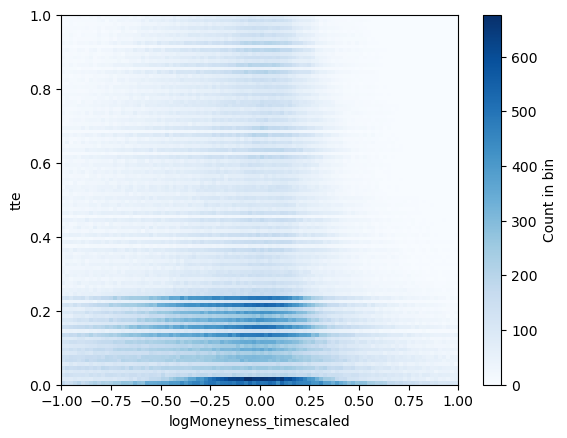

In [37]:
# Sample data
x = optionDataNotCleaned['logMoneynessTimeScaled']
y = optionDataNotCleaned['tte']/365

# Create the heatmap
plt.hist2d(x, y, bins=100, cmap='Blues', range=[[-1, 1], [0, 1]])
plt.colorbar(label='Count in bin')

plt.xlabel('logMoneyness_timescaled')
plt.ylabel('tte')
plt.show()

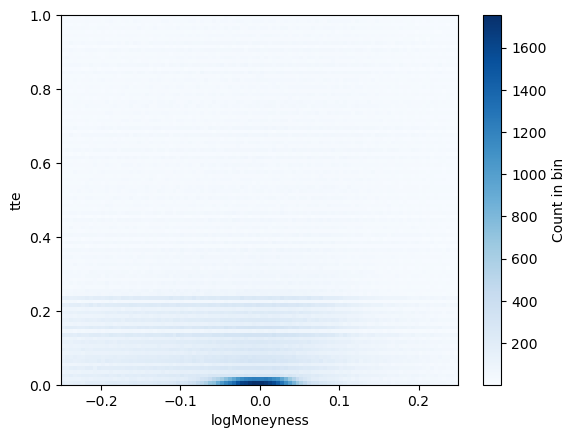

In [38]:
# Sample data
x = optionDataNotCleaned['logMoneyness']
y = optionDataNotCleaned['tte']/365

# Create the heatmap
plt.hist2d(x, y, bins=100, cmap='Blues', range=[[-.25, .25], [0, 1]])
plt.colorbar(label='Count in bin')

plt.xlabel('logMoneyness')
plt.ylabel('tte')
plt.show()

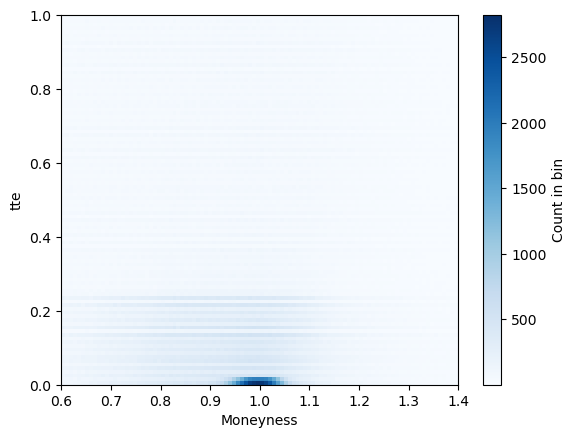

In [39]:
# Sample data
x = optionDataNotCleaned['Moneyness']
y = optionDataNotCleaned['tte']/365

# Create the heatmap
plt.hist2d(x, y, bins=100, cmap='Blues', range=[[.6, 1.4], [0, 1]])
plt.colorbar(label='Count in bin')

plt.xlabel('Moneyness')
plt.ylabel('tte')
plt.show()

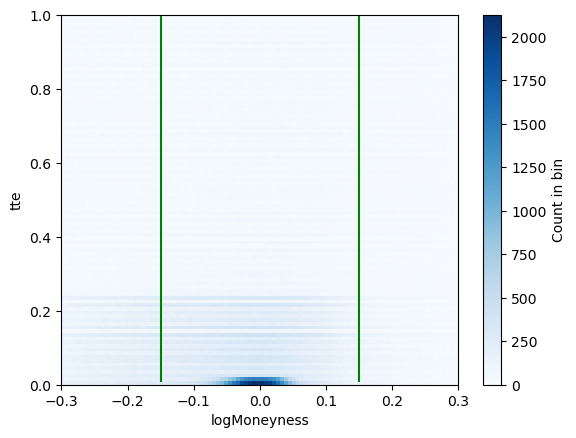

In [192]:
maxLogMoney = .15
minLogMoney = -.15

# Sample data
x = optionDataNotCleaned['logMoneyness']
y = optionDataNotCleaned['tte']/365

# Create the heatmap
plt.hist2d(x, y, bins=100, cmap='Blues', range=[[minLogMoney*2, maxLogMoney*2], [0, 1]])
plt.colorbar(label='Count in bin')

# plt.plot((maxLogMoney*np.sqrt(np.linspace(0.01,1,365))),np.linspace(0.01,1,365), c = 'g')
# plt.plot((minLogMoney*np.sqrt(np.linspace(0.01,1,365))),np.linspace(0.01,1,365), c = 'g')

plt.plot(np.repeat(maxLogMoney,365),np.linspace(0.01,1,365), c = 'g')
plt.plot(np.repeat(minLogMoney,365),np.linspace(0.01,1,365), c = 'g')

plt.xlabel('logMoneyness')
plt.ylabel('tte')
plt.show()

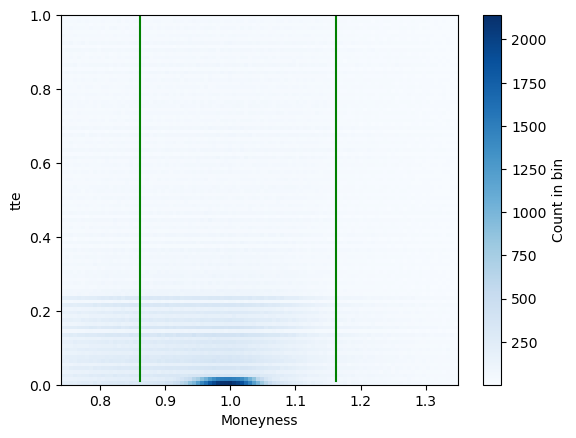

In [44]:
# Sample data
x = optionDataNotCleaned['Moneyness']
y = optionDataNotCleaned['tte']/365

# Create the heatmap
plt.hist2d(x, y, bins=100, cmap='Blues', range=[[np.exp(minLogMoney*2), np.exp(maxLogMoney*2)], [0, 1]])
plt.colorbar(label='Count in bin')

# plt.plot((maxLogMoney*np.sqrt(np.linspace(0.01,1,365))),np.linspace(0.01,1,365), c = 'g')
# plt.plot((minLogMoney*np.sqrt(np.linspace(0.01,1,365))),np.linspace(0.01,1,365), c = 'g')

plt.plot(np.repeat(np.exp(maxLogMoney),365),np.linspace(0.01,1,365), c = 'g')
plt.plot(np.repeat(np.exp(minLogMoney),365),np.linspace(0.01,1,365), c = 'g')

plt.xlabel('Moneyness')
plt.ylabel('tte')
plt.show()

In [193]:
#Could go up to 370 tte to increase obs at the edge to help with B-splines
optionDataLiquid = optionDataNotCleaned[(optionDataNotCleaned['logMoneyness']<=maxLogMoney)&(optionDataNotCleaned['logMoneyness']>=minLogMoney)&(optionDataNotCleaned['tte']<=365)]

In [194]:
optionDataLiquid['logMoneyness'].describe()

count    468470.000000
mean         -0.005733
std           0.077327
min          -0.149999
25%          -0.066062
50%          -0.005816
75%           0.052698
max           0.150000
Name: logMoneyness, dtype: float64

In [195]:
optionDataLiquid.to_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_allData_liquid.csv", index=False)

## Verifying IVS calculation in DJX data

In [196]:
optionDataLiquid = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_allData_liquid.csv")

In [197]:
optionData = optionDataLiquid.copy()

#create empty vector of IV and price based on their IV
implVolVec = []
implMidPrice = []

#compute all IVs
for index, row in optionData[['strike_price','impl_volatility_timeScaled','tte_year','midPrices', 'forward','discountFactors', 'cp_flag']].iterrows():
    print(index) if index%100000 == 0 else ""
    strike, implVol, tau, callMidPrice, forward, discountFactor, cp_flag = row
    callOrPut = ql.Option.Call if cp_flag == 'C' else ql.Option.Put
    implMidPrice.append(ql.blackFormula(callOrPut,strike,forward,implVol, discountFactor))
    try:
        ivsTemp = ql.blackFormulaImpliedStdDev(callOrPut, strike, forward, callMidPrice, discountFactor, 0.0, implVol)
    except RuntimeError:
        ivsTemp = 0
    implVolVec.append(ivsTemp)
   
implVolVec = implVolVec/np.sqrt(optionData['tte_year'])

0
100000
200000
300000
400000


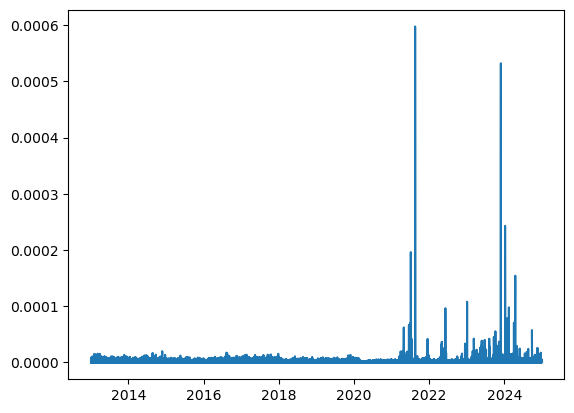

In [198]:
percentErrorPrice = np.abs(implMidPrice - optionData['midPrices'])/optionData['midPrices']
percentErrorVol = np.abs(implVolVec - optionData['impl_volatility'])/optionData['impl_volatility']
optionData['date'] = pd.to_datetime(optionData['date'])
_=plt.plot(optionData['date'],percentErrorVol)
#plt.plot(optionData['tte'].iloc[minEvalIndex:(minEvalIndex+maxEvalIndex)]/36500)
#plt.plot(optionData['date'].iloc[minEvalIndex:(minEvalIndex+maxEvalIndex)].diff().dt.days/200)
#plt.plot(optionData['date'].iloc[minEvalIndex:(minEvalIndex+maxEvalIndex)].dt.month.diff()*1)

In [199]:
optionData['errorPrice'] = np.nan
optionData['errorPrice'] = np.round(percentErrorPrice,4)
print("percent of options with >= .01 error in mid-price computed from given IV:", np.sum(optionData['errorPrice']>=0.01)/optionData.__len__())

percent of options with >= .01 error in mid-price computed from given IV: 0.0


In [ ]:
optionData['impl_volatility_computed'] = implVolVec
optionData['errorVol'] = np.nan
optionData['errorVol'] = np.round(percentErrorVol,4)
print("percent of options with >= .01 error in computed IV:", np.sum(optionData['errorVol']>=0.01)/optionData.__len__())
optionData[optionData['errorVol']>=0.01]

percent of options with >= .01 error in computed IV: 0.0


,date,exdate,am_settlement,cp_flag,strike_price,best_bid,best_offer,impl_volatility,open_interest,volume,...,discountFactors,logForwardMoneynessTimeScaled,logForwardMoneyness,ForwardMoneyness,logMoneynessTimeScaled,logMoneyness,Moneyness,errorPrice,impl_volatility_computed,errorVol


In [124]:
#investigate individual calculations
id = 1183
strike, implVol, tau, callMidPrice, forward, discountFactor, cp_flag, rfRate, implVolYearly, assetPrice, dividendRate = optionData[['strike_price','impl_volatility_timeScaled','tte_year','midPrices', 'forward','discountFactors', 'cp_flag','rfRate','impl_volatility','assetPrices','dividendRate']].iloc[id]
callOrPut = ql.Option.Call if cp_flag == 'C' else ql.Option.Put

tau2 = (tau-1/365)
discountFactor2 = np.exp((rfRate)*(-(tau2)))
implVol2 = implVolYearly*np.sqrt(tau2)
forward2 = assetPrice*np.exp((rfRate-dividendRate)*(tau2))

print(forward2, np.round(tau2*365), implVol2, discountFactor2)


print(forward, strike, np.round(tau*365), implVol, callMidPrice, discountFactor, cp_flag, '\n')
print(ql.blackFormula(callOrPut,strike,forward2,implVol2, discountFactor2))
print(callMidPrice,'\n')
print(ql.blackFormulaImpliedStdDev(callOrPut, strike, forward2, callMidPrice, discountFactor2, 0.0, implVol))
print(implVol2)

135.0379776522684 3.0 0.013380825220574431 0.9999850306051932
135.02730522352385 139.0 4.0 0.015450846086156 0.01 0.9999800408567204 C 

0.009999621915014077
0.01 

0.013380896701852786
0.013380825220574431


In [202]:
optionDataReviewed = optionData[~(optionData['errorVol']>=0.01)]

In [204]:
optionDataReviewedClean = optionDataReviewed[['date', 'tte', 'strike_price', 'assetPrices', 'impl_volatility_computed', 'midPrices', 'rfRate', 'dividendRate', 'cp_flag']]
optionDataReviewedClean.to_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_allData_cleaned_liquid.csv", index=False)

In [205]:
##Optional Remove options with 0 open interest or 0 volume
optionDataReviewedTraded = optionDataReviewed[~(optionDataReviewed['open_interest']<=0)]
optionDataReviewedTraded = optionDataReviewedTraded[~(optionDataReviewedTraded['volume']<=0)]
optionDataReviewedTraded = optionDataReviewedTraded[['date', 'tte', 'strike_price', 'assetPrices', 'impl_volatility_computed', 'midPrices', 'rfRate', 'dividendRate', 'cp_flag']]
optionDataReviewedTraded.to_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_allData_cleaned_liquid_traded.csv", index=False)

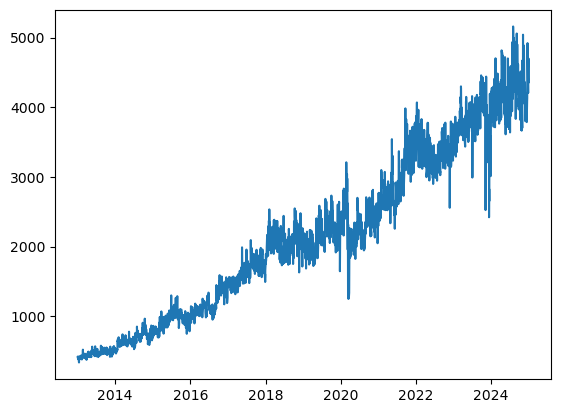

In [ ]:
# optionData = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_allData_cleaned_liquid_traded.csv")
# optionData['date'] = pd.to_datetime(optionData['date'])
# nbObsPerDay = optionData['date'].value_counts().sort_index()
# _=plt.plot(nbObsPerDay)

## Format Data as a list

A panda list where each component in the list is the data for a given day

In [ ]:
# can take quite some time (~40 min)

optionData = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_allData_cleaned_liquid.csv")

uniqueDates = optionData['date'].unique()    

S = []
rfRate = []
dividendRate=[]
tau = []
moneyness = []
iv = []
    
for date in uniqueDates:
    singleDayData = optionData[optionData['date'] == date]
    S.append(singleDayData['assetPrices'].unique()[0])
    rfRate.append(singleDayData['rfRate'])
    dividendRate.append(singleDayData['dividendRate'])
    tau.append(singleDayData['tte']/365)
    moneyness.append(singleDayData['strike_price']/singleDayData['assetPrices'])
    iv.append(singleDayData['impl_volatility_computed'])

with open("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_lists.pkl", "wb") as f:
    pickle.dump(uniqueDates, f)
    pickle.dump(tau, f)
    pickle.dump(moneyness, f)
    pickle.dump(iv, f)
    pickle.dump(S, f)
    pickle.dump(rfRate, f)
    pickle.dump(dividendRate, f)

In [207]:
optionData = pd.read_csv("/Users/macbook/Documents/O_Research/data/DJX_data/DJX_allData_cleaned_liquid.csv")


In [208]:
(optionData[optionData['tte']>=365]['date']).unique().__len__()/optionData['date'].unique().__len__()


0.009271523178807948